# Skenario 1: Cara Encoding Rating untuk Deteksi Inkonsistensi

**Pertanyaan Penelitian:** Dari tiga cara mengintegrasikan informasi rating ke dalam model, mana yang paling efektif untuk mendeteksi inkonsistensi?

| Variant | Cara Encoding Rating | Ilustrasi Input |
|---------|---------------------|-----------------|
| A | Rating sebagai fitur numerik terpisah | teks review + [2] sebagai fitur tambahan di luar model |
| B | Rating di-concat ke representasi [CLS] | teks review → encode → [CLS] ⊕ rating_embedding |
| C | Rating sebagai token di awal teks | [RATING_2] teks review... → masuk bersama ke encoder |

## 1. Setup dan Instalasi

In [1]:
import subprocess, sys

packages = [
    'torch', 'transformers', 'scikit-learn',
    'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

Installing torch...
Installing transformers...
Installing scikit-learn...
Installing pandas...
Installing numpy...
Installing tqdm...
Installing matplotlib...
Installing seaborn...
Semua library berhasil diinstall.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Load dan Persiapan Data

In [3]:
df = pd.read_csv('clean_reviews.csv')
print(f'Total data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')
df.head(3)

Total data: 12,784
Kolom: ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count']


,app,app_id,username,rating,text,text_original,thumbs_up,date,reply,lang,word_count
0,Gojek,com.gojek.app,Pengguna Google,5,saya suka gojek dan semua dr aplikasi ini semo...,saya suka gojek dan semua dr aplikasi ini semo...,0,2026-05-30 16:59:41,NaN,id,13
1,Gojek,com.gojek.app,Pengguna Google,1,"ga pemilik aplikasi nya ,ga pengiklan nya ,ga ...","ga pemilik aplikasi nya ,ga pengiklan nya ,ga ...",1,2026-05-30 16:41:25,NaN,id,14
2,Gojek,com.gojek.app,Pengguna Google,5,"katanya potongan cuma 8%,ke driver. gw dapet o...","katanya potongan cuma 8%,ke driver. gw dapet o...",1,2026-05-30 16:39:05,NaN,id,22


### 2.1 Labeling Sentimen untuk Ground Truth

Kita membuat label sentimen berdasarkan kombinasi rating dan analisis keyword pada teks:
- **Positif**: Rating 4-5 DAN teks mengandung kata positif / tidak mengandung kata negatif
- **Negatif**: Rating 1-2 DAN teks mengandung kata negatif / tidak mengandung kata positif
- **Inkonsisten**: Rating tinggi + teks negatif, ATAU rating rendah + teks positif

In [4]:
POSITIVE_KEYWORDS = [
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'puas', 'senang',
    'membantu', 'mudah', 'cepat', 'lancar', 'recommended', 'terbaik',
    'hebat', 'luar biasa', 'memuaskan', 'nyaman', 'aman', 'top',
    'sempurna', 'praktis', 'berguna', 'terima kasih', 'makasih'
]

NEGATIVE_KEYWORDS = [
    'jelek', 'buruk', 'lambat', 'lemot', 'susah', 'sulit', 'error',
    'bug', 'crash', 'gagal', 'kecewa', 'parah', 'benci', 'sampah',
    'bohong', 'tipu', 'nipu', 'penipuan', 'ribet', 'rumit',
    'tidak bisa', 'gak bisa', 'ga bisa', 'ngga bisa', 'nggak bisa',
    'bermasalah', 'masalah', 'komplain', 'marah', 'kapok'
]

def has_keywords(text, keywords):
    text_lower = str(text).lower()
    return any(kw in text_lower for kw in keywords)

def assign_label(row):
    rating = row['rating']
    text = str(row['text']).lower()

    has_pos = has_keywords(text, POSITIVE_KEYWORDS)
    has_neg = has_keywords(text, NEGATIVE_KEYWORDS)

    # Rating tinggi (4-5) tapi teks negatif → inkonsisten
    if rating >= 4 and has_neg and not has_pos:
        return 1  # inkonsisten
    # Rating rendah (1-2) tapi teks positif → inkonsisten
    if rating <= 2 and has_pos and not has_neg:
        return 1  # inkonsisten
    # Sisanya → konsisten
    return 0  # konsisten

df['label'] = df.apply(assign_label, axis=1)

print(f'Distribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase inkonsisten: {df["label"].mean()*100:.2f}%')

Distribusi label:
label
0    11567
1     1217
Name: count, dtype: int64

Persentase inkonsisten: 9.52%


### 2.2 Balancing Dataset dan Split

In [5]:
# Ambil semua inkonsisten + sample konsisten untuk balance
df_incon = df[df['label'] == 1]
df_con = df[df['label'] == 0].sample(n=min(len(df_incon) * 3, len(df[df['label'] == 0])), random_state=SEED)

df_balanced = pd.concat([df_incon, df_con]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset balanced: {len(df_balanced):,}')
print(df_balanced['label'].value_counts())

# Split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, random_state=SEED, stratify=df_balanced['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Dataset balanced: 4,868
label
0    3651
1    1217
Name: count, dtype: int64

Train: 3,407 | Val: 730 | Test: 731


## 3. Konfigurasi Model

In [6]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 5
LR = 2e-5
NUM_CLASSES = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-base-p1
Vocab size: 30521


## 4. Dataset Classes untuk Setiap Variant

In [7]:
# === VARIANT A: Rating sebagai fitur numerik terpisah ===
class DatasetVariantA(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts = texts
        self.ratings = ratings
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'rating': torch.tensor(self.ratings[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# === VARIANT B: Rating embedding di-concat ke [CLS] ===
class DatasetVariantB(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts = texts
        self.ratings = ratings
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'rating': torch.tensor(self.ratings[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# === VARIANT C: Rating sebagai token di awal teks ===
class DatasetVariantC(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts = [f'[RATING_{r}] {t}' for t, r in zip(texts, ratings)]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

## 5. Model Architectures

In [8]:
# === MODEL VARIANT A: IndoBERT + Rating sebagai fitur numerik ===
class ModelVariantA(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768
        # CLS (768) + rating (1) = 769
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 1, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, rating):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        # Normalize rating to 0-1 range
        rating_norm = (rating / 5.0).unsqueeze(1)  # (batch, 1)
        combined = torch.cat([cls_output, rating_norm], dim=1)  # (batch, 769)
        return self.classifier(combined)

# === MODEL VARIANT B: IndoBERT + Rating Embedding concat ===
class ModelVariantB(nn.Module):
    def __init__(self, model_name, num_classes=2, rating_embed_dim=32):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768
        # Rating 1-5 → embedding (6 entries to handle 0-5 indexing)
        self.rating_embedding = nn.Embedding(6, rating_embed_dim)
        # CLS (768) + rating_embed (32) = 800
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + rating_embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, rating):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS]
        rating_embed = self.rating_embedding(rating)  # (batch, 32)
        combined = torch.cat([cls_output, rating_embed], dim=1)  # (batch, 800)
        return self.classifier(combined)

# === MODEL VARIANT C: IndoBERT standard (rating already in text) ===
class ModelVariantC(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

print('Semua arsitektur model siap.')

Semua arsitektur model siap.


## 6. Training & Evaluation Functions

In [9]:
def train_one_epoch(model, dataloader, optimizer, criterion, variant):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if variant in ['A', 'B']:
            rating = batch['rating'].to(DEVICE)
            outputs = model(input_ids, attention_mask, rating)
        else:  # Variant C
            outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1

def evaluate(model, dataloader, criterion, variant):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            if variant in ['A', 'B']:
                rating = batch['rating'].to(DEVICE)
                outputs = model(input_ids, attention_mask, rating)
            else:
                outputs = model(input_ids, attention_mask)

            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels

## 7. Training Pipeline untuk Ketiga Variant

In [10]:
def run_experiment(variant_name, model_class, dataset_class, train_df, val_df, test_df):
    print(f'\n{"="*60}')
    print(f'TRAINING VARIANT {variant_name}')
    print(f'{"="*60}')

    # Prepare datasets
    train_ds = dataset_class(
        train_df['text'].values, train_df['rating'].values,
        train_df['label'].values, tokenizer, MAX_LEN
    )
    val_ds = dataset_class(
        val_df['text'].values, val_df['rating'].values,
        val_df['label'].values, tokenizer, MAX_LEN
    )
    test_ds = dataset_class(
        test_df['text'].values, test_df['rating'].values,
        test_df['label'].values, tokenizer, MAX_LEN
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    # Init model
    if variant_name == 'A':
        model = model_class(MODEL_NAME, NUM_CLASSES).to(DEVICE)
    elif variant_name == 'B':
        model = model_class(MODEL_NAME, NUM_CLASSES, rating_embed_dim=32).to(DEVICE)
    else:
        model = model_class(MODEL_NAME, NUM_CLASSES).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f'\nEpoch {epoch+1}/{EPOCHS}')

        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, variant_name)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, variant_name)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
        print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict().copy()
            print(f'  ✓ Best model updated (F1: {best_val_f1:.4f})')

    # Load best model & evaluate on test
    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, variant_name)

    print(f'\n--- Test Results (Variant {variant_name}) ---')
    print(f'Test Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(test_labels, test_preds, target_names=['Konsisten', 'Inkonsisten']))

    return {
        'variant': variant_name,
        'history': history,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'test_preds': test_preds,
        'test_labels': test_labels,
        'model': model
    }

## 8. Jalankan Eksperimen

In [11]:
results = {}

# Variant A: Rating sebagai fitur numerik terpisah
results['A'] = run_experiment('A', ModelVariantA, DatasetVariantA, train_df, val_df, test_df)


TRAINING VARIANT A


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Epoch 1/5


...

  Train Loss: 0.4582 | Acc: 0.7749 | F1: 0.7492
  Val   Loss: 0.5330 | Acc: 0.7685 | F1: 0.7224
  ✓ Best model updated (F1: 0.7224)

Epoch 3/5


  Train Loss: 0.3169 | Acc: 0.8638 | F1: 0.8617
  Val   Loss: 0.6247 | Acc: 0.7247 | F1: 0.7217

Epoch 4/5


  Train Loss: 0.1963 | Acc: 0.9252 | F1: 0.9247
  Val   Loss: 0.7040 | Acc: 0.7466 | F1: 0.7376
  ✓ Best model updated (F1: 0.7376)

Epoch 5/5


  Train Loss: 0.1047 | Acc: 0.9645 | F1: 0.9644
  Val   Loss: 1.1110 | Acc: 0.7438 | F1: 0.7287



--- Test Results (Variant A) ---
Test Loss: 0.9800 | Acc: 0.7510 | F1: 0.7414

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.81      0.87      0.84       548
 Inkonsisten       0.50      0.40      0.45       183

    accuracy                           0.75       731
   macro avg       0.66      0.64      0.64       731
weighted avg       0.74      0.75      0.74       731



In [12]:
# Variant B: Rating di-concat ke representasi [CLS]
results['B'] = run_experiment('B', ModelVariantB, DatasetVariantB, train_df, val_df, test_df)


TRAINING VARIANT B


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Epoch 1/5


  Train Loss: 0.5388 | Acc: 0.7499 | F1: 0.6595
  Val   Loss: 0.5349 | Acc: 0.7575 | F1: 0.6643
  ✓ Best model updated (F1: 0.6643)

Epoch 2/5


  Train Loss: 0.4580 | Acc: 0.7802 | F1: 0.7509
  Val   Loss: 0.4719 | Acc: 0.7753 | F1: 0.7248
  ✓ Best model updated (F1: 0.7248)

Epoch 3/5


  Train Loss: 0.3468 | Acc: 0.8456 | F1: 0.8413
  Val   Loss: 0.5464 | Acc: 0.7575 | F1: 0.7513
  ✓ Best model updated (F1: 0.7513)

Epoch 4/5


  Train Loss: 0.1777 | Acc: 0.9304 | F1: 0.9305
  Val   Loss: 0.7272 | Acc: 0.7699 | F1: 0.7545
  ✓ Best model updated (F1: 0.7545)

Epoch 5/5


  Train Loss: 0.1050 | Acc: 0.9645 | F1: 0.9645
  Val   Loss: 0.8568 | Acc: 0.7452 | F1: 0.7491



--- Test Results (Variant B) ---
Test Loss: 0.8526 | Acc: 0.7428 | F1: 0.7459

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.84      0.82      0.83       548
 Inkonsisten       0.49      0.52      0.51       183

    accuracy                           0.74       731
   macro avg       0.66      0.67      0.67       731
weighted avg       0.75      0.74      0.75       731



In [13]:
# Variant C: Rating sebagai token di awal teks
results['C'] = run_experiment('C', ModelVariantC, DatasetVariantC, train_df, val_df, test_df)


TRAINING VARIANT C


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Epoch 1/5


  Train Loss: 0.5428 | Acc: 0.7446 | F1: 0.6552
  Val   Loss: 0.5082 | Acc: 0.7493 | F1: 0.6431
  ✓ Best model updated (F1: 0.6431)

Epoch 2/5


  Train Loss: 0.4378 | Acc: 0.7901 | F1: 0.7757
  Val   Loss: 0.3980 | Acc: 0.8219 | F1: 0.8061
  ✓ Best model updated (F1: 0.8061)

Epoch 3/5


  Train Loss: 0.2651 | Acc: 0.8891 | F1: 0.8889
  Val   Loss: 0.3493 | Acc: 0.8822 | F1: 0.8743
  ✓ Best model updated (F1: 0.8743)

Epoch 4/5


  Train Loss: 0.1400 | Acc: 0.9507 | F1: 0.9509
  Val   Loss: 0.4511 | Acc: 0.8603 | F1: 0.8559

Epoch 5/5


  Train Loss: 0.0801 | Acc: 0.9736 | F1: 0.9736
  Val   Loss: 0.4959 | Acc: 0.8808 | F1: 0.8775
  ✓ Best model updated (F1: 0.8775)



--- Test Results (Variant C) ---
Test Loss: 0.5715 | Acc: 0.8782 | F1: 0.8762

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.91      0.93      0.92       548
 Inkonsisten       0.78      0.71      0.74       183

    accuracy                           0.88       731
   macro avg       0.84      0.82      0.83       731
weighted avg       0.88      0.88      0.88       731



## 9. Perbandingan Hasil

In [18]:
print('=' * 60)
print('PERBANDINGAN HASIL KETIGA VARIANT')
print('=' * 60)

comparison = pd.DataFrame({
    'Variant': ['A (Fitur Numerik)', 'B (Rating Embedding)', 'C (Token di Teks)'],
    'Test Accuracy': [results[v]['test_acc'] for v in ['A', 'B', 'C']],
    'Test F1-Score': [results[v]['test_f1'] for v in ['A', 'B', 'C']],
})

display(comparison)

best_variant = comparison.loc[comparison['Test F1-Score'].idxmax()]
print(f'\n Variant terbaik: {best_variant["Variant"]}')
print(f'   Accuracy: {best_variant["Test Accuracy"]:.4f}')
print(f'   F1-Score: {best_variant["Test F1-Score"]:.4f}')

PERBANDINGAN HASIL KETIGA VARIANT


,Variant,Test Accuracy,Test F1-Score
0,A (Fitur Numerik),0.751026,0.741405
1,B (Rating Embedding),0.742818,0.745892
2,C (Token di Teks),0.878249,0.876214



 Variant terbaik: C (Token di Teks)
   Accuracy: 0.8782
   F1-Score: 0.8762


## 10. Visualisasi

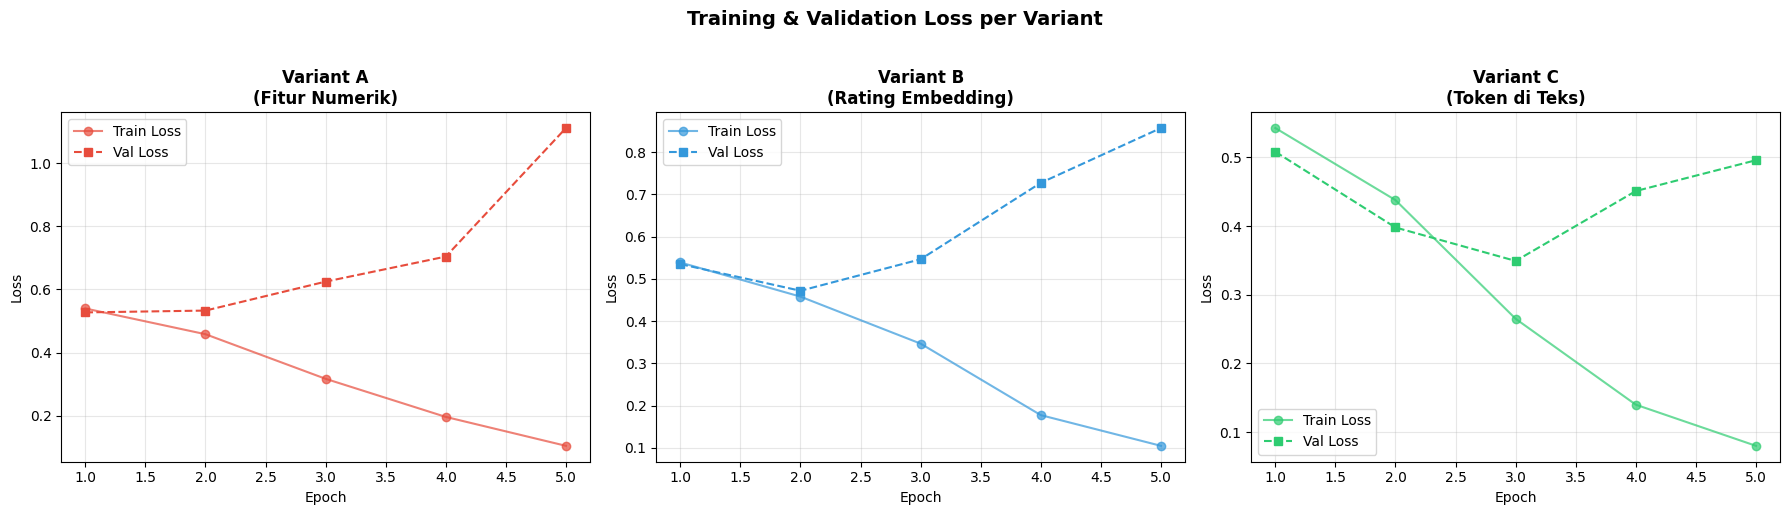

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71'}
titles = {'A': 'Variant A\n(Fitur Numerik)', 'B': 'Variant B\n(Rating Embedding)', 'C': 'Variant C\n(Token di Teks)'}

for i, v in enumerate(['A', 'B', 'C']):
    ax = axes[i]
    h = results[v]['history']
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, h['train_loss'], '-o', label='Train Loss', color=colors[v], alpha=0.7)
    ax.plot(epochs_range, h['val_loss'], '--s', label='Val Loss', color=colors[v])
    ax.set_title(titles[v], fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss per Variant', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skenario1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

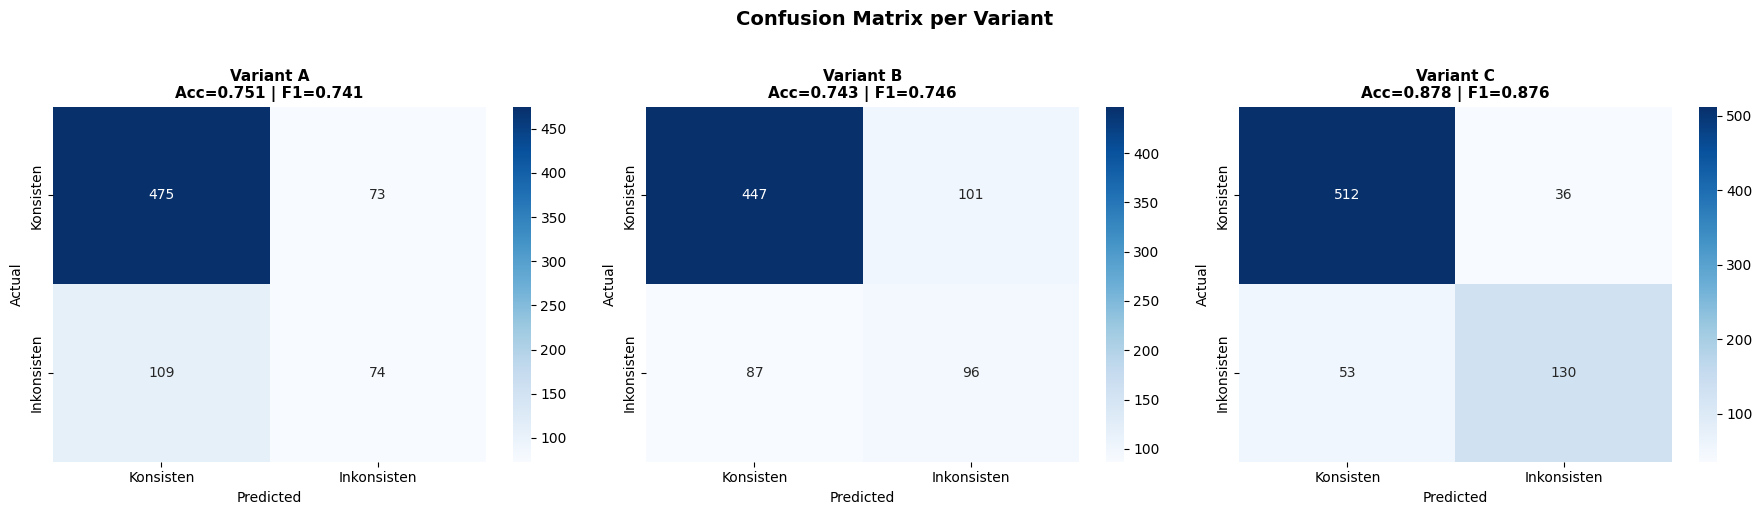

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, v in enumerate(['A', 'B', 'C']):
    ax = axes[i]
    cm = confusion_matrix(results[v]['test_labels'], results[v]['test_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Konsisten', 'Inkonsisten'],
                yticklabels=['Konsisten', 'Inkonsisten'])
    ax.set_title(f'Variant {v}\nAcc={results[v]["test_acc"]:.3f} | F1={results[v]["test_f1"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix per Variant', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skenario1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

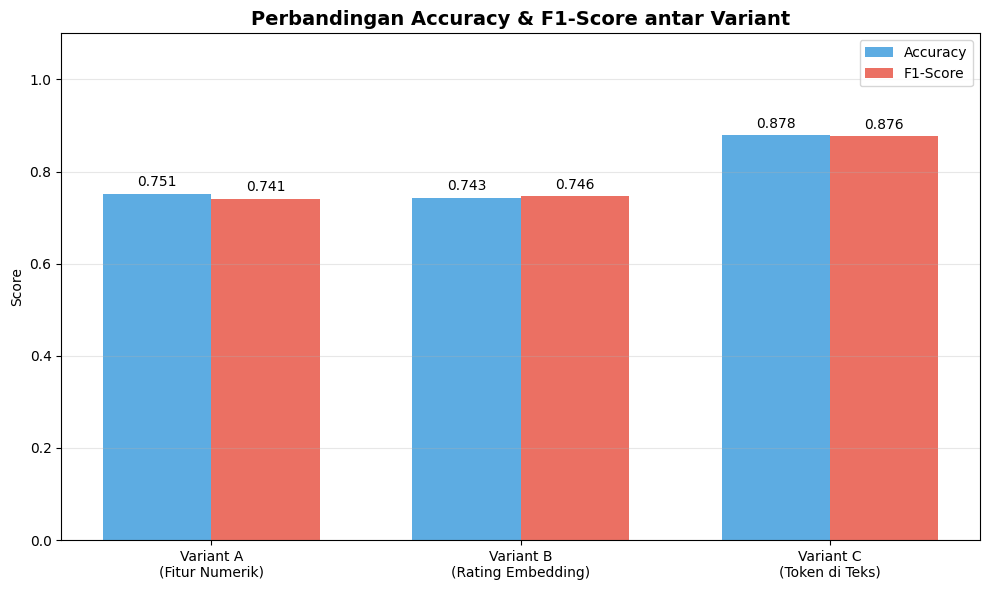

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(3)
width = 0.35
acc_vals = [results[v]['test_acc'] for v in ['A', 'B', 'C']]
f1_vals = [results[v]['test_f1'] for v in ['A', 'B', 'C']]

bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_vals, width, label='F1-Score', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Variant A\n(Fitur Numerik)', 'Variant B\n(Rating Embedding)', 'Variant C\n(Token di Teks)'])
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy & F1-Score antar Variant', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('skenario1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Kesimpulan

Berdasarkan eksperimen Skenario 1, kita telah membandingkan tiga cara encoding rating:

- **Variant A**: Rating sebagai fitur numerik terpisah (di-concat setelah [CLS])
- **Variant B**: Rating di-embed lalu di-concat ke representasi [CLS]
- **Variant C**: Rating dimasukkan sebagai token teks `[RATING_X]` di awal input

Berdasarkan hasil uji coba skenario 1, variant C merupakan performa terbaik dibandikan kedua variant lainnya.